In [1]:
import nltk
import numpy as np
import networkx as nx
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
import re
from collections import Counter
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer

# First, I will download the Punkt tokeniser models for sentence splitting and work tokenisation
nltk.download('punkt')
# Then, I will download the part-of-speech (POS) tagging model which is necessary for identifying noun phrases in the text
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

df = pd.read_pickle(r"data_preprocessed.pkl")
print("Number of rows:", df.shape[0])
print("Columns:", df.columns.tolist())
text_column='abstract'
# Using regex for valid words
Valid_word=re.compile(r'^[a-zA-Z\-]+$')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Number of rows: 27121
Columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions', 'year', 'cleaned_abstract', 'period']


In [2]:
# This function will calculate universal IDF to measure word importance for all of the abstracts
def calculate_universal_IDF(preprocessed_tokens_list):
    N=len(preprocessed_tokens_list)
    document_frequency=Counter()
    for tokens in tqdm(preprocessed_tokens_list, desc="IDF Progress"):
        unique_words=set(tokens)
        document_frequency.update(unique_words)
    idf={w: np.log(N / (1 + f)) for w, f in document_frequency.items()}
    return idf
preprocessed_tokens_list=[str(text).split() for text in df[text_column].tolist()]
universal_IDF=calculate_universal_IDF(preprocessed_tokens_list)

# By this, I will convert a sentence into a numerical vector using TF-IDF
def sentence_vector(tokens, vocabulary, universal_IDF):
    if not tokens:
        return np.zeros(len(vocabulary))
    vector=np.zeros(len(vocabulary))
    Term_frequency=Counter(tokens)
    for word, count in Term_frequency.items():
        if word in vocabulary:
            vector[vocabulary[word]]=(count / len(tokens)) * universal_IDF.get(word, 1.0)
    return vector

IDF Progress: 100%|██████████| 27121/27121 [00:00<00:00, 29405.91it/s]


In [3]:
# This function converts text into sentences and a numerical vocabulary so that TextRank can calculate sentence importance
def textrank_summarise(preprocessed_text, top_n=3, position_bias=0.3):
    if not isinstance(preprocessed_text, str):
        return preprocessed_text
    sentences=sent_tokenize(preprocessed_text)
    if len(sentences) <= top_n:
        return preprocessed_text
    all_words=set(preprocessed_text.split())
    vocabulary={w: i for i, w in enumerate(all_words)}

    # Now, I will convert all sentences into normalised numerical vectors so they can be fairly based on their similarities
    vectors=np.array([sentence_vector(sent.split(), vocabulary, universal_IDF) for sent in sentences])
    norm=np.linalg.norm(vectors, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    vectors=vectors / norm
    
    # Then here, I am computing cosine similarity between all pairs of sentences
    similarity_matrix=np.clip(vectors @ vectors.T, 0, None)
    np.fill_diagonal(similarity_matrix, 0)
    # Converting the similarity matrix into a graph using NetworkX
    Graph_sentences=nx.from_numpy_array(similarity_matrix)
    # Then, I will apply PageRank algorithm to the graph
    scores=nx.pagerank(Graph_sentences, max_iter=200, tol=1e-6)

    position_raw=np.exp(-0.5 * np.arange(len(sentences)))
    # Normalising the raw position scores so they sum to 1
    position_score=position_raw / position_raw.sum()
    final_scores={i: (1 - position_bias) * scores[i] + position_bias * position_score[i] for i in range(len(sentences))}
    # Here, I will pick the top important sentences based on the combined score
    ranked_index_row=sorted(final_scores, key=final_scores.get, reverse=True)[:top_n]

    return ' '.join(sentences[i] for i in sorted(ranked_index_row))

# I am using Penn Treebank tags to define the structure of a Noun phrase
Noun_Phrase_Grammar=r'KP: {(<JJ.*>|<NN.*>)*<NN.*>}'
Noun_Phrase_Parser=nltk.RegexpParser(Noun_Phrase_Grammar)

In [4]:
# This function will extract noun phrases from the text using the defined grammar and filter them based on length and valid characters
def extract_noun_phrases(text):
    tokens=word_tokenize(text)
    tagged=nltk.pos_tag(tokens)
    tree=Noun_Phrase_Parser.parse(tagged)
    phrases = []
    
    for subtree in tree.subtrees(filter=lambda t: t.label() == 'KP'):
        words = [w.lower() for w, _ in subtree.leaves()]
        valid_words = [w for w in words if Valid_word.match(w)]
        # filtering out phrases on the basis of length and valid characters
        if 1 <= len(valid_words) <= 5:
            phrase=' '.join(valid_words)
            phrases.append(phrase)
    return phrases

# I will use this function to remove redundant keyphrases that are substrings of each other
def filter_redundant_phrases(ranked_phrases, top_n):
    filtered=[]
    for phrase in ranked_phrases:
        if not any(phrase in f or f in phrase for f in filtered):
            filtered.append(phrase)
        if len(filtered) >= top_n:
            break
    return filtered

In [ ]:
# Finally, I have made this function, which will extract and rank important keyphrases using TextRank graph
def textrank_keyphrases(text, top_n=10, window=5):
    if not isinstance(text, str):
        return []
    phrases=extract_noun_phrases(text)
    if len(phrases) < 3:
        return phrases[:top_n]
    unique_phrases=list(dict.fromkeys(phrases))
    Graph_sentences=nx.Graph()
    Graph_sentences.add_nodes_from(unique_phrases)
    for i, p in enumerate(phrases):
        for q in phrases[i+1:i+window]:
            if p != q:
                if Graph_sentences.has_edge(p, q):
                    Graph_sentences[p][q]['weight'] += 1
                else:
                    Graph_sentences.add_edge(p, q, weight=1)

    # Applying the PageRank
    PageRank=nx.pagerank(Graph_sentences, weight='weight', max_iter=200, tol=1e-6)
    
    # It is the final scoring function
    def final_score(phrase):
        return PageRank.get(phrase, 0) * (1 + 0.15 * (len(phrase.split()) - 1))
    ranked=sorted(unique_phrases, key=final_score, reverse=True)

    return filter_redundant_phrases(ranked, top_n)

print("\nRunning TextRank summarisation and keyphrase extraction in parallel")

def process_summaries(texts):
    return [textrank_summarise(t) for t in texts]

def process_keyphrases(texts):
    return [textrank_keyphrases(t) for t in texts]

# Splitting the data into chunks for parallel processing
n_cores=joblib.cpu_count()
text_chunks=np.array_split(df[text_column].astype(str), n_cores)

# Running the parallel summarisation
df['summary']=sum( joblib.Parallel(n_jobs=n_cores)( joblib.delayed(process_summaries)(chunk) for chunk in tqdm(text_chunks, desc="Summarising") ), [] )

# Running the parallel keyphrase extraction
df['keyphrases']=sum( joblib.Parallel(n_jobs=n_cores)( joblib.delayed(process_keyphrases)(chunk) for chunk in tqdm(text_chunks, desc="Extracting Keyphrases") ), [] )

pd.set_option('display.max_colwidth', 120)
print("First 3 rows")
for index_row, row in df[[text_column,'year','summary','keyphrases']].head(3).iterrows():
    print(f"\n[Row {index_row}]")
    print(f"Year: {row['year']}")
    print(f"Summary: {str(row['summary'])[:200]}")
    print(f"Keyphrases: {', '.join(row['keyphrases'])}")
df.to_pickle("data_with_nlp.pkl")
df[[text_column, 'year', 'summary', 'keyphrases']].to_csv("nlp_results.csv", index=False)
print("\nSaved data_with_nlp.pkl and nlp_results.csv")


Running TextRank summarisation and keyphrase extraction in parallel


C:\Users\clare\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
Extracting Keyphrases: 100%|██████████| 8/8 [00:00<00:00, 4717.34it/s]


In [9]:
# Loading the data from pickle file
lemmatizer=WordNetLemmatizer()
df=pd.read_pickle("data_with_nlp.pkl")

bins=[2007, 2012, 2017, 2022]
labels=["2007–2011", "2012–2016", "2017–2021"]
df['year_bin']=pd.cut(df['year'], bins=bins, labels=labels, right=False)

# This function removes plural "s" if it's a simple word ending in s
def clean_phrase(text):
    tokens=text.split()
    lemmas=[lemmatizer.lemmatize(t) for t in tokens]
    cleaned=[]
    for t in lemmas:
        if len(t) > 3 and t.endswith("s") and not t.endswith("ss"):
            t=t[:-1]
        cleaned.append(t)
    return " ".join(cleaned)

# Here, I keep phrases that actually represent meaningful AI methods
AI_methods=["support vector machine", "svm", "convolutional neural network", "cnn", "recurrent neural network", "rnn", "transformer", "bert", "self attention", "attention mechanism", "reinforcement learning", "backpropagation", "stochastic gradient descent", "gradient descent", "deep learning" ]

# Here, I filter out generic terms
Generic_terms=set(["feature", "features", "accuracy", "prediction", "loss", "classification", "regression", "network", "neural", "nlp", "vision", "learning", "model", "models", "training", "dataset", "datasets", "machine", "optimization", "gradient", "clustering"])

df_exploded=df[['year_bin', 'keyphrases']].explode('keyphrases')
df_exploded=df_exploded.dropna()
df_exploded['keyphrases']=df_exploded['keyphrases'].apply(clean_phrase)


 AI/ML Research Activity Score
    year_bin  ai_ml_research_activity_score
0  2007–2011                             31
1  2012–2016                            171
2  2017–2021                           1667

Top AIML Keyphrases per Era
       year_bin                           keyphrases  count
892   2007–2011                                  svm      6
708   2007–2011     reproducing kernel hilbert space      4
420   2007–2011                        hilbert space      2
893   2007–2011                       svm classifier      2
137   2007–2011                                c-svm      1
239   2007–2011                    decomposition svm      1
367   2007–2011                general hilbert space      1
371   2007–2011                   general scaled svm      1
386   2007–2011                               gs-svm      1
389   2007–2011  hard margin pattern recognition svm      1
1934  2012–2016                                  svm     19
1754  2012–2016                            

/var/folders/qt/x__x40j92pgbxt_27rm62m2m0000gn/T/ipykernel_43923/3939364663.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  growth_score= (df_exploded.groupby('year_bin').size().reset_index(name='ai_ml_research_activity_score'))
/var/folders/qt/x__x40j92pgbxt_27rm62m2m0000gn/T/ipykernel_43923/3939364663.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend=(df_exploded.groupby(['year_bin', 'keyphrases']) .size() .reset_index(name='count').sort_values(['year_bin','count'], ascending=[True, False]) )
/var/folders/qt/x__x40j92pgbxt_27rm62m2m0000gn/T/ipykernel_43923/3939364663.py:18: FutureWarning: The 

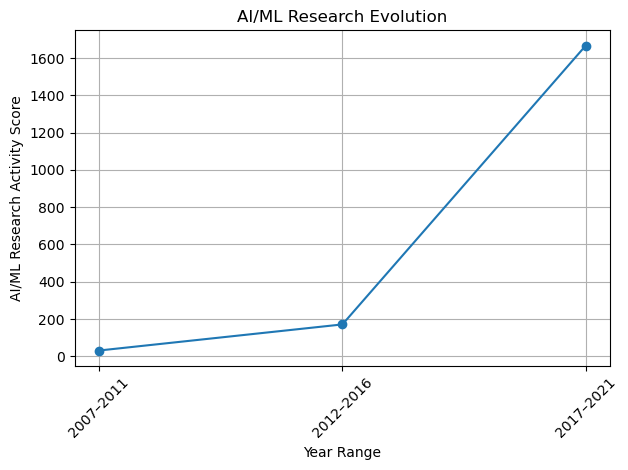

In [10]:
# This function checks if a keyphrase is relevant to AIML
def valid_ai_ml(text):
    text=str(text)
    signal_keyword=any(phrase in text for phrase in AI_methods)
    # rejecting if it contains generic words
    tokens=set(text.split())
    noise=any(term in tokens for term in Generic_terms)

    return signal_keyword and not noise
df_exploded=df_exploded[df_exploded['keyphrases'].apply(valid_ai_ml)]

growth_score= (df_exploded.groupby('year_bin').size().reset_index(name='ai_ml_research_activity_score'))
print("\n AI/ML Research Activity Score")
print(growth_score)

# These are the top Keyphrases per era
trend=(df_exploded.groupby(['year_bin', 'keyphrases']) .size() .reset_index(name='count').sort_values(['year_bin','count'], ascending=[True, False]) )
top_trends=trend.groupby('year_bin').head(10)
print("\nTop AIML Keyphrases per Era")
print(top_trends)

plt.figure()
plt.plot(growth_score['year_bin'].astype(str),growth_score['ai_ml_research_activity_score'],marker='o')
plt.xlabel("Year Range")
plt.ylabel("AI/ML Research Activity Score")
plt.title("AI/ML Research Evolution")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()